<a href="https://colab.research.google.com/github/GabrielThiel/ethereum-fraud-analysis/blob/main/notebooks/01-exploracao-datasets.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Análise de Fraudes em Transações da Rede Ethereum

## Objetivo

Este notebook será utilizado para realizar a exploração, análise e preparação de datasets relacionados a transações da rede Ethereum, com foco na identificação de padrões associados a fraude, comportamento anômalo e endereços suspeitos.

## Etapas

1. Exploração inicial dos datasets
2. Análise da estrutura dos dados
3. Identificação de valores ausentes e inconsistentes
4. Limpeza e preparação dos dados
5. Análise das características (features)
6. Estudo das relações entre as features
7. Seleção das features relevantes
8. Visualização dos dados
9. Avaliação da possibilidade de integração entre datasets
10. Preparação do dataset final para modelos de aprendizado de máquina

## Bibliotecas

- Pandas
- Polars
- Matplotlib
- Scikit-learn

## Observação

As decisões de limpeza, seleção de features e integração dos datasets serão documentadas ao longo do projeto.

In [1]:
import pandas as pd
import polars as pl
import matplotlib.pyplot as plt
import sklearn

print("Pandas:", pd.__version__)
print("Polars:", pl.__version__)
print("Scikit-learn:", sklearn.__version__)

Pandas: 2.2.3
Polars: 1.35.2
Scikit-learn: 1.6.1


In [2]:
import os

os.listdir("/content")

['.config', 'sample_data']

In [3]:
os.listdir("/content")

['.config', 'archive.zip', 'sample_data']

In [4]:
import zipfile

zip_path = "/content/archive.zip"

with zipfile.ZipFile(zip_path, "r") as zip_ref:
    print("Arquivos dentro do ZIP:")
    for arquivo in zip_ref.namelist():
        print(arquivo)

Arquivos dentro do ZIP:
ETFD_Dataset.txt


In [5]:
import zipfile
import os

zip_path = "/content/archive.zip"
extract_path = "/content/etfd"

with zipfile.ZipFile(zip_path, "r") as zip_ref:
    zip_ref.extractall(extract_path)

print(os.listdir(extract_path))

['ETFD_Dataset.txt']


In [6]:
arquivo = "/content/etfd/ETFD_Dataset.txt"

with open(arquivo, "r", encoding="utf-8") as f:
    for i in range(10):
        print(repr(f.readline()))

'blockNumber\tconfirmations\tMonth\tDay\tHour\tmean_value_received\tvariance_value_received\ttotal_received\ttime_diff_first_last_received\ttotal_tx_sent\ttotal_tx_sent_malicious\ttotal_tx_sent_unique\ttotal_tx_sent_malicious_unique\ttotal_tx_received_malicious_unique\tFraud\n'
'19664511\t201879\t4\t16\t0\t0.1751904075\t0.0519971092909851\t0.7007616300000001\t246.45916666666668\t43.0\t0.0\t6.0\t0.0\t0.0\t0\n'
'16217669\t3648727\t12\t19\t8\t0.0842392024381043\t0.0344684110324226\t13.394033187658586\t625.4894328703704\t62.0\t0.0\t1.0\t0.0\t0.0\t0\n'
'14351953\t5514270\t3\t9\t10\t3.896735904391325\t101.819167885204\t467.608308526959\t1884.80613425926\t552.0\t0.0\t251.0\t0.0\t0.0\t0\n'
'19753020\t113094\t4\t28\t9\t0.1355401416682591\t0.0043894645704178\t1.4909415583508507\t225.1555555555556\t59.0\t0.0\t33.0\t0.0\t0.0\t0\n'
'19076055\t790248\t1\t24\t10\t0.2357174086643617\t0.1490361968081223\t43.372003194242566\t937.6813773148148\t423.0\t0.0\t97.0\t0.0\t0.0\t0\n'
'11530191\t8336003\t12\t26\

In [7]:
df_etfd = pd.read_csv(
    "/content/etfd/ETFD_Dataset.txt",
    sep="\t"
)

print("Dimensões:", df_etfd.shape)
print("\nColunas:")
print(df_etfd.columns.tolist())

Dimensões: (85003, 15)

Colunas:
['blockNumber', 'confirmations', 'Month', 'Day', 'Hour', 'mean_value_received', 'variance_value_received', 'total_received', 'time_diff_first_last_received', 'total_tx_sent', 'total_tx_sent_malicious', 'total_tx_sent_unique', 'total_tx_sent_malicious_unique', 'total_tx_received_malicious_unique', 'Fraud']


In [8]:
print("Distribuição da variável Fraud:")
print(df_etfd["Fraud"].value_counts())

print("\nValores nulos:")
print(df_etfd.isnull().sum())

print("\nDuplicatas:")
print(df_etfd.duplicated().sum())

print("\nTipos das colunas:")
print(df_etfd.dtypes)

Distribuição da variável Fraud:
Fraud
1    42504
0    42499
Name: count, dtype: int64

Valores nulos:
blockNumber                           0
confirmations                         0
Month                                 0
Day                                   0
Hour                                  0
mean_value_received                   0
variance_value_received               0
total_received                        0
time_diff_first_last_received         0
total_tx_sent                         0
total_tx_sent_malicious               0
total_tx_sent_unique                  0
total_tx_sent_malicious_unique        0
total_tx_received_malicious_unique    0
Fraud                                 0
dtype: int64

Duplicatas:
1533

Tipos das colunas:
blockNumber                             int64
confirmations                           int64
Month                                   int64
Day                                     int64
Hour                                    int64
mean_value_receiv

In [9]:
duplicados = df_etfd[df_etfd.duplicated(keep=False)]

print("Total de registros envolvidos em duplicatas:", len(duplicados))

print("\nQuantidade de grupos duplicados:")
print(
    duplicados
    .value_counts()
    .head(10)
)

Total de registros envolvidos em duplicatas: 2347

Quantidade de grupos duplicados:
blockNumber  confirmations  Month  Day  Hour  mean_value_received  variance_value_received  total_received  time_diff_first_last_received  total_tx_sent  total_tx_sent_malicious  total_tx_sent_unique  total_tx_sent_malicious_unique  total_tx_received_malicious_unique  Fraud
18612163     1253932        11     20   9     0.0                  0.0                      0.0             0.0                            1.0            0.0                      1.0                   0.0                             0.0                                 0        26
4080765      15686565       7      27   12    0.0                  0.0                      0.0             0.0                            1.0            1.0                      1.0                   1.0                             0.0                                 1        26
4080766      15686564       7      27   12    0.0                  0.0         

In [10]:
print(duplicados.head(10))

     blockNumber  confirmations  Month  Day  Hour  mean_value_received  \
27      19594020         272335      4    6     3             0.000000   
30      19478485         387634      3   20    21             0.000000   
104     13938512        5927764      1    4    10             0.000000   
232     17739992        2126519      7   21     7             0.000000   
453     19485142         381392      3   21    19             0.000000   
508     17683402        2183109      7   13     8             1.818397   
672     13535674        6330820     11    2     5             1.364448   
821     18849083        1017449     12   23    14             0.000000   
848     19494658         371782      3   23     3             0.000000   
976     15522645        4343624      9   12    19             0.084252   

     variance_value_received  total_received  time_diff_first_last_received  \
27                  0.000000        0.000000                       0.000000   
30                  0.00000

In [11]:
# Verifica se existem registros com as mesmas features,
# mas com classificações Fraud diferentes.

features = [col for col in df_etfd.columns if col != "Fraud"]

conflitos = (
    df_etfd
    .groupby(features)["Fraud"]
    .nunique()
)

conflitos = conflitos[conflitos > 1]

print("Quantidade de grupos com conflito de classificação:", len(conflitos))

Quantidade de grupos com conflito de classificação: 0


In [12]:
if len(conflitos) > 0:
    print("\nExemplos de conflitos:")
    print(conflitos.head(10))
else:
    print("\nNenhum conflito encontrado.")


Nenhum conflito encontrado.


In [13]:
df_etfd_sem_duplicatas = df_etfd.drop_duplicates()

print("Registros antes:", len(df_etfd))
print("Registros depois:", len(df_etfd_sem_duplicatas))
print("Registros removidos:", len(df_etfd) - len(df_etfd_sem_duplicatas))

print("\nDistribuição das classes após remoção:")
print(df_etfd_sem_duplicatas["Fraud"].value_counts())

Registros antes: 85003
Registros depois: 83470
Registros removidos: 1533

Distribuição das classes após remoção:
Fraud
0    42200
1    41270
Name: count, dtype: int64


## Análise e tratamento de duplicatas

Na análise inicial do dataset ETFD foram identificados 1.533 registros
duplicados.

Antes de realizar a remoção, foi verificado se existiam registros com
as mesmas características (features), mas associados a classes diferentes
na variável `Fraud`.

Não foram encontrados conflitos de classificação.

Dessa forma, os registros duplicados foram considerados redundantes para
a análise e a remoção foi considerada apropriada.

### Resultado

- Registros originais: 85.003
- Registros duplicados removidos: 1.533
- Registros após a remoção: 83.470
- `Fraud = 0`: 42.200
- `Fraud = 1`: 41.270

A distribuição das classes permaneceu aproximadamente equilibrada após
a remoção das duplicatas.

In [14]:
df_etfd_sem_duplicatas.describe().T

,count,mean,std,min,25%,50%,75%,max
blockNumber,83470.0,1.146481e+07,5.822563e+06,1311219.0,5747731.75,11738664.0,1.729350e+07,1.986646e+07
confirmations,83470.0,8.352634e+06,5.779062e+06,6.0,2572708.75,8098807.0,1.402083e+07,1.855500e+07
Month,83470.0,6.023613e+00,3.251159e+00,1.0,3.00,6.0,9.000000e+00,1.200000e+01
Day,83470.0,1.577437e+01,8.686819e+00,1.0,8.00,16.0,2.300000e+01,3.100000e+01
Hour,83470.0,1.218169e+01,6.607071e+00,0.0,7.00,13.0,1.800000e+01,2.300000e+01
mean_value_received,83470.0,4.679450e+00,3.189324e+01,0.0,0.00,0.0,4.941925e-01,7.501000e+02
variance_value_received,83470.0,4.140936e+03,3.478089e+04,0.0,0.00,0.0,4.074424e-01,1.124700e+06
total_received,83470.0,4.045047e+03,3.257804e+04,0.0,0.00,0.0,2.467630e+01,2.817010e+05
time_diff_first_last_received,83470.0,3.095189e+02,5.221020e+02,0.0,0.00,0.0,5.070435e+02,2.986429e+03
total_tx_sent,83470.0,6.544432e+02,1.760126e+03,1.0,2.00,26.0,4.630000e+02,9.996000e+03


In [15]:
# Verificar valores negativos
print("Valores negativos por coluna:")
print((df_etfd_sem_duplicatas < 0).sum())

# Verificar quantidade e percentual de zeros
print("\nValores iguais a zero:")

zeros = (df_etfd_sem_duplicatas == 0).sum()
percentual_zeros = (zeros / len(df_etfd_sem_duplicatas) * 100).round(2)

resultado_zeros = pd.DataFrame({
    "quantidade": zeros,
    "percentual": percentual_zeros
})

print(resultado_zeros)

Valores negativos por coluna:
blockNumber                           0
confirmations                         0
Month                                 0
Day                                   0
Hour                                  0
mean_value_received                   0
variance_value_received               0
total_received                        0
time_diff_first_last_received         0
total_tx_sent                         0
total_tx_sent_malicious               0
total_tx_sent_unique                  0
total_tx_sent_malicious_unique        0
total_tx_received_malicious_unique    0
Fraud                                 0
dtype: int64

Valores iguais a zero:
                                    quantidade  percentual
blockNumber                                  0        0.00
confirmations                                0        0.00
Month                                        0        0.00
Day                                          0        0.00
Hour                                  

## Análise de valores negativos e zeros

Foi realizada uma análise para identificar valores negativos e valores
iguais a zero nas variáveis do dataset ETFD.

Não foram encontrados valores negativos em nenhuma das variáveis.

Foi observada, entretanto, uma elevada concentração de valores iguais a
zero em algumas características. A variável `total_tx_received_malicious_unique`
apresentou 94,62% de valores iguais a zero, enquanto outras variáveis
relacionadas a transações maliciosas apresentaram aproximadamente 56,20%
de valores iguais a zero.

Os valores zero não foram considerados automaticamente como dados
incorretos, pois podem representar situações válidas no contexto das
transações da rede Ethereum. Dessa forma, nenhuma variável foi removida
nesta etapa com base apenas na quantidade de zeros.

In [16]:
print("Quantidade de valores únicos por coluna:\n")

valores_unicos = df_etfd_sem_duplicatas.nunique().sort_values()

print(valores_unicos)

Quantidade de valores únicos por coluna:

Fraud                                     2
total_tx_received_malicious_unique        8
Month                                    12
Hour                                     24
Day                                      31
total_tx_sent_malicious_unique           47
total_tx_sent_malicious                  57
total_tx_sent_unique                    179
total_tx_sent                           397
variance_value_received                4932
time_diff_first_last_received          5028
total_received                         5720
mean_value_received                    5766
blockNumber                           81766
confirmations                         82104
dtype: int64


In [17]:
print("\nFeatures com apenas um valor:")

features_constantes = valores_unicos[valores_unicos == 1]

print(features_constantes)


Features com apenas um valor:
Series([], dtype: int64)


## Análise de variabilidade das features

Foi analisada a quantidade de valores únicos presentes em cada coluna
para identificar possíveis características constantes.

Nenhuma das variáveis apresentou apenas um valor distinto. Portanto,
não foram identificadas features constantes que pudessem ser removidas
com base exclusivamente na ausência de variabilidade.

A variável `total_tx_received_malicious_unique` apresentou apenas 8
valores distintos, porém essa característica não foi removida nesta
etapa, pois uma baixa quantidade de valores distintos não implica,
isoladamente, ausência de poder preditivo.

In [18]:
correlacao = df_etfd_sem_duplicatas.corr()

correlacao

,blockNumber,confirmations,Month,Day,Hour,mean_value_received,variance_value_received,total_received,time_diff_first_last_received,total_tx_sent,total_tx_sent_malicious,total_tx_sent_unique,total_tx_sent_malicious_unique,total_tx_received_malicious_unique,Fraud
blockNumber,1.000000,-0.999992,-0.085223,0.025180,-0.043880,0.098894,0.096273,0.103397,0.307038,0.192195,-0.083367,0.176091,-0.221154,-0.133065,-0.881178
confirmations,-0.999992,1.000000,0.085103,-0.025234,0.043623,-0.098574,-0.096003,-0.103133,-0.306151,-0.191331,0.082096,-0.175672,0.220992,0.132924,0.879261
Month,-0.085223,0.085103,1.000000,-0.022942,0.022558,-0.016267,-0.018381,-0.019837,0.021282,-0.063808,-0.009771,-0.016603,-0.082779,-0.042158,0.088868
Day,0.025180,-0.025234,-0.022942,1.000000,0.006138,-0.009050,-0.007223,-0.002872,0.010170,0.000158,0.008160,0.040744,0.011617,0.012509,-0.015846
Hour,-0.043880,0.043623,0.022558,0.006138,1.000000,-0.048113,-0.046711,-0.050613,-0.025438,-0.036403,0.031824,-0.005585,-0.003729,-0.003624,0.068609
mean_value_received,0.098894,-0.098574,-0.016267,-0.009050,-0.048113,1.000000,0.976424,0.896267,0.160738,0.443311,-0.029604,-0.035510,-0.027321,-0.005747,-0.124132
variance_value_received,0.096273,-0.096003,-0.018381,-0.007223,-0.046711,0.976424,1.000000,0.912015,0.136472,0.457579,-0.027352,-0.041931,-0.027859,-0.016528,-0.115878
total_received,0.103397,-0.103133,-0.019837,-0.002872,-0.050613,0.896267,0.912015,1.000000,0.148397,0.528380,-0.028280,-0.033616,-0.028584,-0.016330,-0.121480
time_diff_first_last_received,0.307038,-0.306151,0.021282,0.010170,-0.025438,0.160738,0.136472,0.148397,1.000000,0.088077,-0.064456,0.096096,-0.014509,0.162602,-0.374177
total_tx_sent,0.192195,-0.191331,-0.063808,0.000158,-0.036403,0.443311,0.457579,0.528380,0.088077,1.000000,0.055377,0.462169,0.000821,0.001894,-0.269745


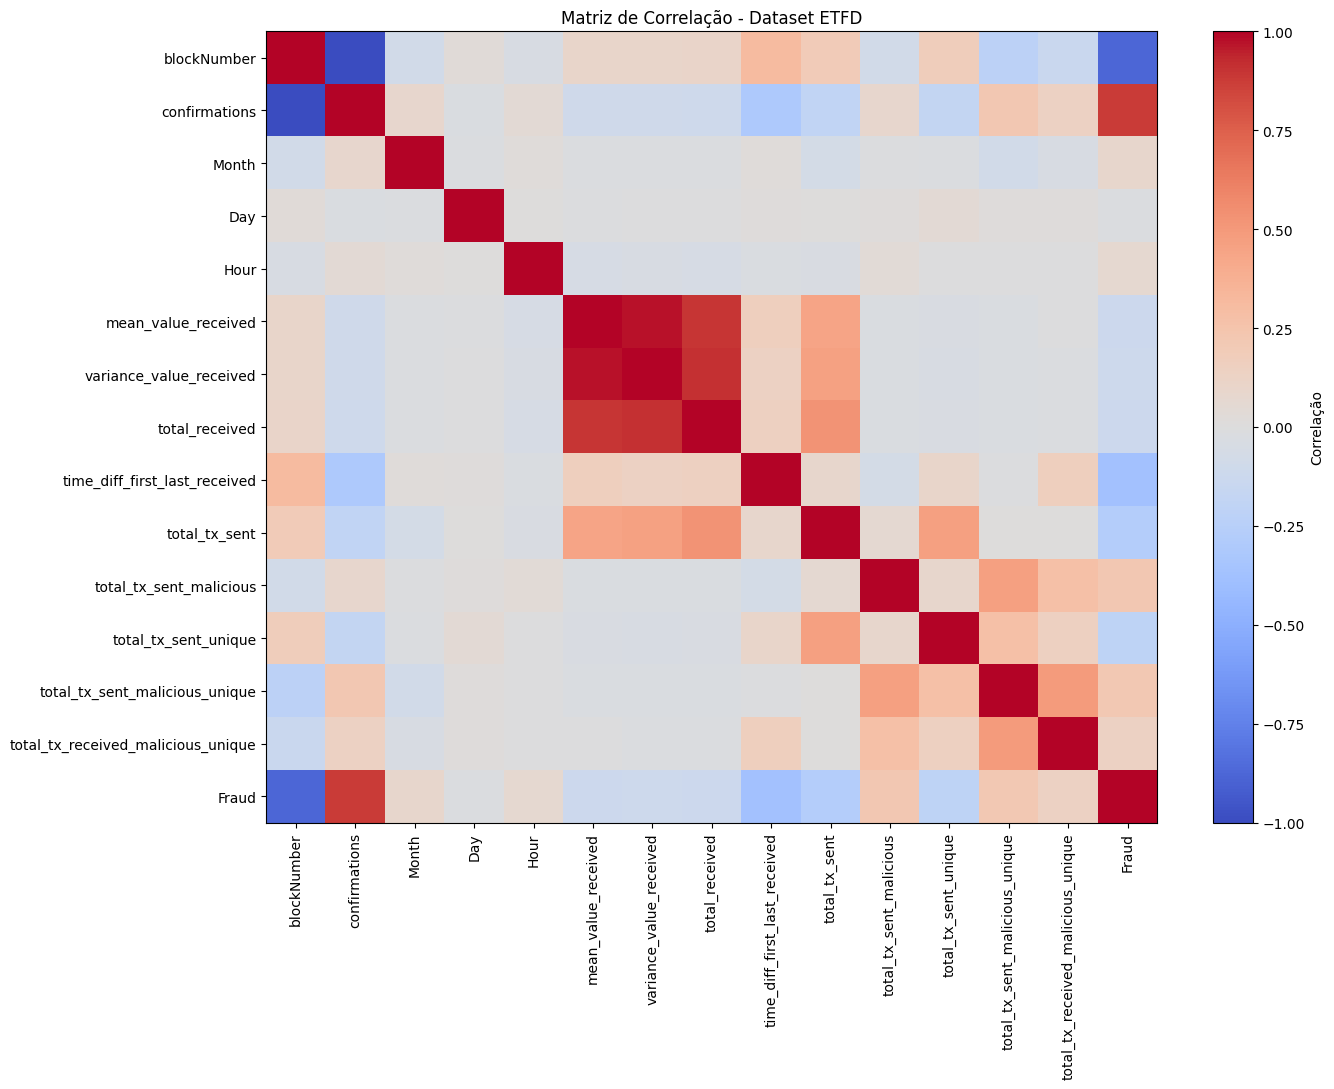

In [19]:
import matplotlib.pyplot as plt

plt.figure(figsize=(14, 11))

plt.imshow(correlacao, cmap="coolwarm", aspect="auto", vmin=-1, vmax=1)

plt.colorbar(label="Correlação")

plt.xticks(
    range(len(correlacao.columns)),
    correlacao.columns,
    rotation=90
)

plt.yticks(
    range(len(correlacao.index)),
    correlacao.index
)

plt.title("Matriz de Correlação - Dataset ETFD")

plt.tight_layout()
plt.show()

## Análise de correlação

Foi calculada a matriz de correlação entre as variáveis numéricas do
dataset ETFD e posteriormente gerado um heatmap utilizando Matplotlib.

Foi identificada uma correlação extremamente forte e negativa entre
`blockNumber` e `confirmations` (aproximadamente -0,999992), indicando
que essas variáveis possuem comportamento altamente relacionado.

Também foram observadas correlações elevadas entre `mean_value_received`,
`variance_value_received` e `total_received`.

Em relação à variável-alvo `Fraud`, as maiores correlações foram
observadas com `blockNumber` (-0,881178) e `confirmations` (0,879261).

Esses resultados não foram utilizados isoladamente para remover
variáveis. As features com alta correlação serão investigadas
posteriormente considerando seu significado, possível redundância e
eventual risco de vazamento de informação (data leakage).

In [20]:
# Relação entre blockNumber e confirmations

df_etfd_sem_duplicatas["block_confirmations_sum"] = (
    df_etfd_sem_duplicatas["blockNumber"] +
    df_etfd_sem_duplicatas["confirmations"]
)

df_etfd_sem_duplicatas["block_confirmations_diff"] = (
    df_etfd_sem_duplicatas["blockNumber"] -
    df_etfd_sem_duplicatas["confirmations"]
)

print("Estatísticas da soma:")
print(df_etfd_sem_duplicatas["block_confirmations_sum"].describe())

print("\nEstatísticas da diferença:")
print(df_etfd_sem_duplicatas["block_confirmations_diff"].describe())

Estatísticas da soma:
count    8.347000e+04
mean     1.981744e+07
std      4.941146e+04
min      1.976733e+07
25%      1.976745e+07
50%      1.986606e+07
75%      1.986630e+07
max      1.986653e+07
Name: block_confirmations_sum, dtype: float64

Estatísticas da diferença:
count    8.347000e+04
mean     3.112172e+06
std      1.160160e+07
min     -1.724379e+07
25%     -8.273614e+06
50%      3.636778e+06
75%      1.472090e+07
max      1.986640e+07
Name: block_confirmations_diff, dtype: float64


/tmp/ipykernel_3622/1694632101.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_etfd_sem_duplicatas["block_confirmations_sum"] = (
/tmp/ipykernel_3622/1694632101.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_etfd_sem_duplicatas["block_confirmations_diff"] = (


In [21]:
df_etfd_sem_duplicatas[
    ["blockNumber", "confirmations"]
].head(20)

,blockNumber,confirmations
0,19664511,201879
1,16217669,3648727
2,14351953,5514270
3,19753020,113094
4,19076055,790248
5,11530191,8336003
6,18817741,1048774
7,18637845,1228302
8,19068121,797945
9,12189510,7676543


In [22]:
from sklearn.linear_model import LinearRegression

X = df_etfd_sem_duplicatas[["blockNumber"]]
y = df_etfd_sem_duplicatas["confirmations"]

modelo_relacao = LinearRegression()
modelo_relacao.fit(X, y)

print("Coeficiente:", modelo_relacao.coef_[0])
print("Intercepto:", modelo_relacao.intercept_)
print("R²:", modelo_relacao.score(X, y))

Coeficiente: -0.9925206602742654
Intercepto: 19731691.4445638
R²: 0.9999836819498155


In [23]:
df_etfd_sem_duplicatas = df_etfd_sem_duplicatas.drop(
    columns=["block_confirmations_sum", "block_confirmations_diff"],
    errors="ignore"
).copy()

In [24]:
relacao_blocos = (
    df_etfd_sem_duplicatas["blockNumber"] +
    df_etfd_sem_duplicatas["confirmations"]
)

print("Quantidade de valores diferentes:", relacao_blocos.nunique())

print("\nEstatísticas:")
print(relacao_blocos.describe())

print("\nMenores valores:")
print(relacao_blocos.nsmallest(10).tolist())

print("\nMaiores valores:")
print(relacao_blocos.nlargest(10).tolist())

Quantidade de valores diferentes: 633

Estatísticas:
count    8.347000e+04
mean     1.981744e+07
std      4.941146e+04
min      1.976733e+07
25%      1.976745e+07
50%      1.986606e+07
75%      1.986630e+07
max      1.986653e+07
dtype: float64

Menores valores:
[19767328, 19767328, 19767328, 19767328, 19767328, 19767328, 19767328, 19767328, 19767328, 19767328]

Maiores valores:
[19866534, 19866534, 19866534, 19866534, 19866534, 19866534, 19866534, 19866534, 19866534, 19866534]


## Investigação da relação entre `blockNumber` e `confirmations`

Para investigar a forte correlação observada entre `blockNumber` e
`confirmations`, foi calculada a soma das duas variáveis.

A soma apresentou 633 valores distintos, variando de 19.767.328 a
19.866.534 blocos. A existência de diferentes valores de referência
indica que `confirmations` não parece ter sido calculado em relação a
uma única altura de bloco para todo o dataset.

Os resultados são compatíveis com uma relação aproximada entre as
variáveis na forma:

`confirmations ≈ altura_do_bloco_de_referência - blockNumber`

Essa relação explica a correlação extremamente forte e negativa
observada anteriormente.

A relação será investigada adicionalmente antes de qualquer decisão
sobre remoção de uma das variáveis, especialmente devido à possibilidade
de redundância e de vazamento de informação (data leakage).

In [25]:
analise_temporal = (
    df_etfd_sem_duplicatas
    .groupby("blockNumber")["Fraud"]
    .agg(["count", "mean"])
)

analise_temporal["percentual_fraude"] = (
    analise_temporal["mean"] * 100
)

print(analise_temporal.describe())

              count          mean  percentual_fraude
count  81766.000000  81766.000000       81766.000000
mean       1.020840      0.488830          48.882991
std        0.163003      0.499802          49.980215
min        1.000000      0.000000           0.000000
25%        1.000000      0.000000           0.000000
50%        1.000000      0.000000           0.000000
75%        1.000000      1.000000         100.000000
max        9.000000      1.000000         100.000000


In [26]:
# Dividir blockNumber em 20 faixas de tamanho semelhante

df_temporal = df_etfd_sem_duplicatas.copy()

df_temporal["faixa_bloco"] = pd.qcut(
    df_temporal["blockNumber"],
    q=20,
    duplicates="drop"
)

analise_faixas = (
    df_temporal
    .groupby("faixa_bloco", observed=True)["Fraud"]
    .agg(
        quantidade="count",
        quantidade_fraude="sum",
        percentual_fraude="mean"
    )
)

analise_faixas["percentual_fraude"] *= 100

analise_faixas

,quantidade,quantidade_fraude,percentual_fraude
faixa_bloco,,,
"(1311218.999, 4536241.4]",4174,4015,96.190704
"(4536241.4, 5030448.4]",4173,3740,89.623772
"(5030448.4, 5289304.45]",4174,3713,88.955438
"(5289304.45, 5510854.4]",4173,4038,96.764917
"(5510854.4, 5747731.75]",4174,4123,98.778150
"(5747731.75, 5998690.1]",4173,4088,97.963096
"(5998690.1, 6306548.3]",4174,4130,98.945855
"(6306548.3, 6365519.4]",4173,4170,99.928109
"(6365519.4, 7406806.55]",4174,4052,97.077144


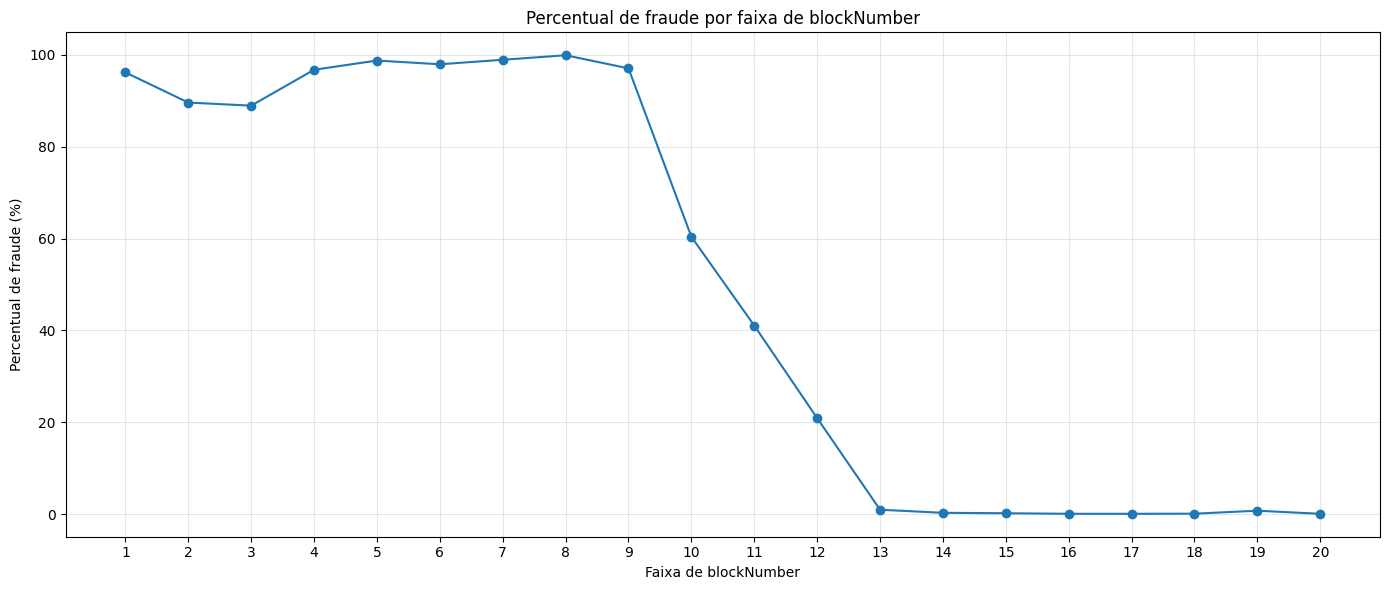

In [27]:
plt.figure(figsize=(14, 6))

plt.plot(
    range(1, len(analise_faixas) + 1),
    analise_faixas["percentual_fraude"],
    marker="o"
)

plt.xlabel("Faixa de blockNumber")
plt.ylabel("Percentual de fraude (%)")
plt.title("Percentual de fraude por faixa de blockNumber")
plt.xticks(range(1, len(analise_faixas) + 1))
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## Análise temporal da variável `Fraud`

Para investigar a forte correlação observada entre `blockNumber` e a
variável-alvo `Fraud`, os registros foram divididos em 20 faixas de
`blockNumber` com quantidades aproximadamente iguais de observações.

Foi observada uma forte variação da proporção de transações fraudulentas
ao longo das faixas. Nas primeiras faixas, a proporção de fraude ficou
próxima de 90% a 100%, enquanto nas faixas posteriores caiu para valores
próximos de 0%.

Esse comportamento indica uma forte dependência temporal entre
`blockNumber` e a variável `Fraud`.

O resultado exige investigação adicional da origem e do processo de
rotulagem do dataset antes da seleção definitiva das features e da
construção dos modelos de classificação.

Essa análise também levanta a possibilidade de dependência temporal ou
vazamento de informação, caso a variável `blockNumber` permita ao modelo
inferir a classe principalmente a partir do período em que a observação
foi registrada.